# 01 — Data exploration

Characterise HAI and Morris as DatasetBundles. All logic lives in `src/data_loader.py`; this notebook only describes and plots.


In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_hai, load_morris
from src.utils import save_figure, set_seed

set_seed(42)
sns.set_theme(style='whitegrid', context='notebook')


## Bundles

In [2]:
hai = load_hai()
morris = load_morris()

summary = pd.DataFrame([{
    'dataset': 'HAI 21.03',
    'rows': len(hai.labels),
    'features': hai.features.shape[1],
    'train': int((hai.split == 'train').sum()),
    'val':   int((hai.split == 'val').sum()),
    'test':  int((hai.split == 'test').sum()),
    'attack_rate_test': float(hai.y('test').mean()),
}, {
    'dataset': 'Morris gas',
    'rows': len(morris.labels),
    'features': morris.features.shape[1],
    'train': int((morris.split == 'train').sum()),
    'val':   int((morris.split == 'val').sum()),
    'test':  int((morris.split == 'test').sum()),
    'attack_rate_test': float(morris.y('test').mean()),
}])
summary


,dataset,rows,features,train,val,test,attack_rate_test
0,HAI 21.03,1323608,79,783363,138240,402005,0.022256
1,Morris gas,196393,16,84274,22983,89136,0.484305


## HAI attack-type breakdown

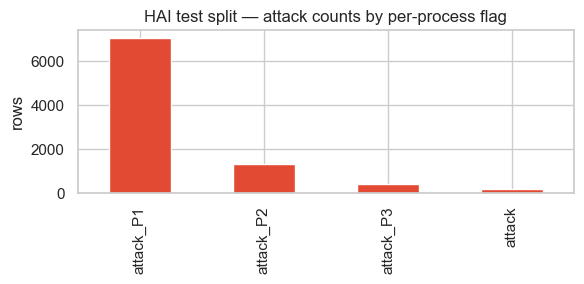

In [3]:
mask = hai.mask('test') & (hai.labels > 0)
ac = pd.Series(hai.attack_ids[mask]).value_counts()
fig, ax = plt.subplots(figsize=(6, 3))
ac.plot(kind='bar', ax=ax, color='#e34a33')
ax.set_title('HAI test split — attack counts by per-process flag')
ax.set_ylabel('rows')
plt.tight_layout()
save_figure(fig, 'hai_attack_breakdown', subdir='01_exploration')
plt.show()


## Sensor trace with attack windows

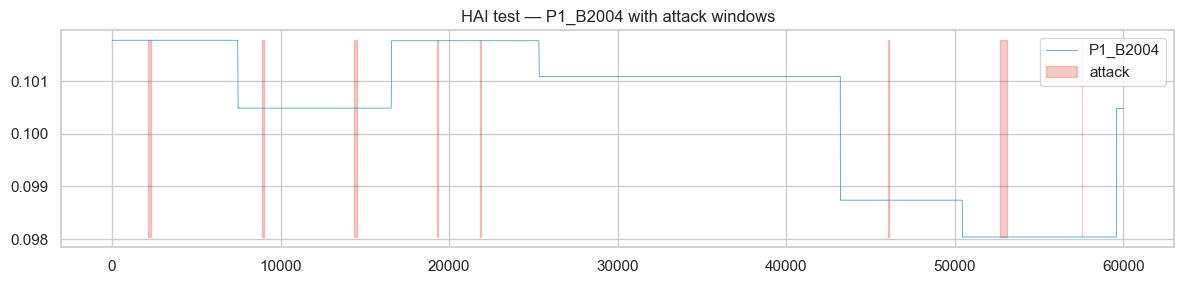

In [4]:
col = hai.features.columns[0]
series = hai.features[col].to_numpy()
is_test = hai.mask('test')
series = series[is_test][:60000]
labels = hai.labels[is_test][:60000]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(series, color='#2b8cbe', linewidth=0.5, label=col)
ax.fill_between(
    np.arange(len(series)), series.min(), series.max(),
    where=labels.astype(bool), color='#de2d26', alpha=0.25, label='attack',
)
ax.set_title(f'HAI test — {col} with attack windows')
ax.legend(loc='upper right')
plt.tight_layout()
save_figure(fig, 'hai_attack_windows', subdir='01_exploration')
plt.show()


## Morris feature correlation

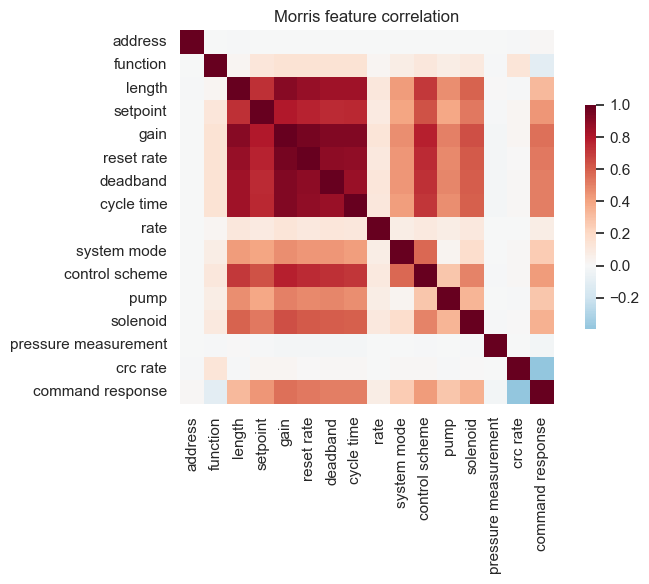

In [5]:
corr = morris.features.corr().fillna(0)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap='RdBu_r', center=0, square=True, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.6})
ax.set_title('Morris feature correlation')
plt.tight_layout()
save_figure(fig, 'morris_correlation', subdir='01_exploration')
plt.show()
